In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Load dataset (built into seaborn — no file needed) ─────────────────
titanic = sns.load_dataset('titanic')

# Feature engineering
titanic['Survived_label'] = titanic['survived'].map({0: 'Died', 1: 'Survived'})
titanic['Class']          = titanic['pclass'].map({1: '1st', 2: '2nd', 3: '3rd'})
titanic['Sex_label']      = titanic['sex'].str.capitalize()
titanic['FamilySize']     = titanic['sibsp'] + titanic['parch'] + 1
titanic['IsAlone']        = (titanic['FamilySize'] == 1).map({True: 'Alone', False: 'With Family'})

print(titanic.shape)
titanic.head()

(891, 20)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Survived_label,Class,Sex_label,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,Died,3rd,Male,2,With Family
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Survived,1st,Female,2,With Family
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Survived,3rd,Female,1,Alone
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Survived,1st,Female,2,With Family
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,Died,3rd,Male,1,Alone


In [2]:
print("Shape:", titanic.shape)
print()
print(titanic[['survived','pclass','sex','age','fare',
               'embarked','sibsp','parch']].describe(include='all').T)

Shape: (891, 20)

          count unique   top freq       mean        std   min     25%  \
survived  891.0    NaN   NaN  NaN   0.383838   0.486592   0.0     0.0   
pclass    891.0    NaN   NaN  NaN   2.308642   0.836071   1.0     2.0   
sex         891      2  male  577        NaN        NaN   NaN     NaN   
age       714.0    NaN   NaN  NaN  29.699118  14.526497  0.42  20.125   
fare      891.0    NaN   NaN  NaN  32.204208  49.693429   0.0  7.9104   
embarked    889      3     S  644        NaN        NaN   NaN     NaN   
sibsp     891.0    NaN   NaN  NaN   0.523008   1.102743   0.0     0.0   
parch     891.0    NaN   NaN  NaN   0.381594   0.806057   0.0     0.0   

              50%   75%       max  
survived      0.0   1.0       1.0  
pclass        3.0   3.0       3.0  
sex           NaN   NaN       NaN  
age          28.0  38.0      80.0  
fare      14.4542  31.0  512.3292  
embarked      NaN   NaN       NaN  
sibsp         0.0   1.0       8.0  
parch         0.0   0.0       6.0  


In [3]:
miss = titanic.isnull().sum()
miss = miss[miss > 0]
print("Missing values:")
print(miss)

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


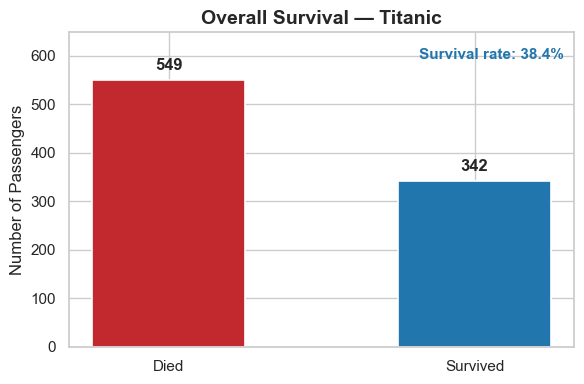

In [4]:
counts = titanic['Survived_label'].value_counts().reindex(['Died','Survived'])

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(counts.index, counts.values,
              color=['#C1292E','#2176AE'], width=0.5,
              edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', padding=5, fontsize=12, fontweight='bold')

ax.set_title('Overall Survival — Titanic', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, counts.max() * 1.18)

# survival rate annotation
rate = titanic['survived'].mean()
ax.text(0.98, 0.95, f'Survival rate: {rate:.1%}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color='#2176AE', fontweight='bold')

plt.tight_layout()
plt.show()

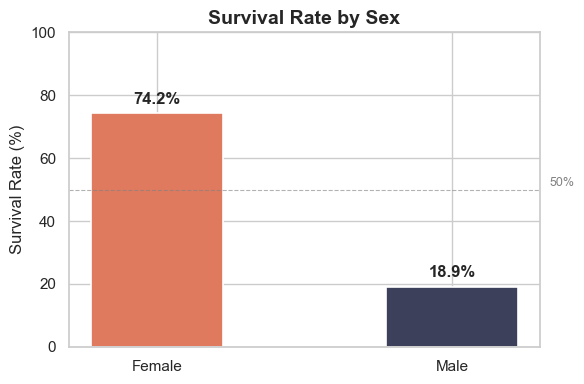

In [5]:
sex_surv = titanic.groupby('Sex_label')['survived'].mean().reset_index()
sex_surv.columns = ['Sex', 'SurvivalRate']
sex_surv['SurvivalRate_pct'] = sex_surv['SurvivalRate'] * 100

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(sex_surv['Sex'], sex_surv['SurvivalRate_pct'],
              color=['#E07A5F','#3D405B'], width=0.45,
              edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=12, fontweight='bold')

ax.set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(50, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(1.02, 51, '50%', transform=ax.get_yaxis_transform(),
        color='grey', fontsize=9)

plt.tight_layout()
plt.show()